
# 04 — Online Retail Customer & Product Analytics

**Product Pulse**

Analyze cleaned Online Retail II sales for revenue, products, countries, repeat purchasing, and customer value.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "02_cleaned"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed data folder not found: {PROCESSED_DIR}\n"
        "Run 02_data_cleaning_and_validation.ipynb first."
    )


PROJECT_ROOT : /Users/noopur/Desktop/resume_projects/ProductPulse
PROCESSED_DIR: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned


In [2]:

RETAIL_PATH = PROCESSED_DIR / "online_retail_sales_clean.parquet"
if not RETAIL_PATH.exists(): raise FileNotFoundError(RETAIL_PATH)
retail = pd.read_parquet(RETAIL_PATH)
print("Shape:",retail.shape)
print("Date range:",retail["InvoiceDate"].min(),"→",retail["InvoiceDate"].max())
display(retail.head())


Shape: (1029609, 10)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,source_sheet,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.0


## 1. Business overview

In [3]:

orders_total = retail["Invoice"].nunique(); customers_total = retail["CustomerID"].nunique(dropna=True); products_total = retail["StockCode"].nunique(); revenue_total = retail["Revenue"].sum()
business_overview = pd.DataFrame({"metric":["sales_rows","orders","identified_customers","products","countries","revenue","average_order_value"],"value":[len(retail),orders_total,customers_total,products_total,retail["Country"].nunique(),round(revenue_total,2),round(revenue_total/orders_total,2) if orders_total else np.nan]})
display(business_overview)


,metric,value
0,sales_rows,1029609.00
1,orders,40077.00
2,identified_customers,5878.00
3,products,4916.00
4,countries,43.00
5,revenue,20913891.47
6,average_order_value,521.84


## 2. Monthly revenue and orders

In [4]:

retail["month"] = retail["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
monthly_metrics = retail.groupby("month").agg(revenue=("Revenue","sum"),orders=("Invoice","nunique"),customers=("CustomerID","nunique"),units=("Quantity","sum")).reset_index().sort_values("month")
monthly_metrics["avg_order_value"] = monthly_metrics["revenue"] / monthly_metrics["orders"]
display(monthly_metrics.tail(12))


,month,revenue,orders,customers,units,avg_order_value
13,2011-01-01,689811.610,1086,741,387099,635.185645
14,2011-02-01,522545.560,1100,758,282934,475.041418
15,2011-03-01,716215.260,1454,974,376599,492.582710
16,2011-04-01,536968.491,1246,856,307953,430.953845
17,2011-05-01,769296.610,1681,1056,395001,457.642243
18,2011-06-01,760547.010,1533,991,388511,496.116771
19,2011-07-01,718076.121,1475,949,399693,486.831268
20,2011-08-01,757841.380,1361,935,421020,556.826877
21,2011-09-01,1056435.192,1837,1266,569573,575.087203
22,2011-10-01,1151263.730,2040,1364,621029,564.344966


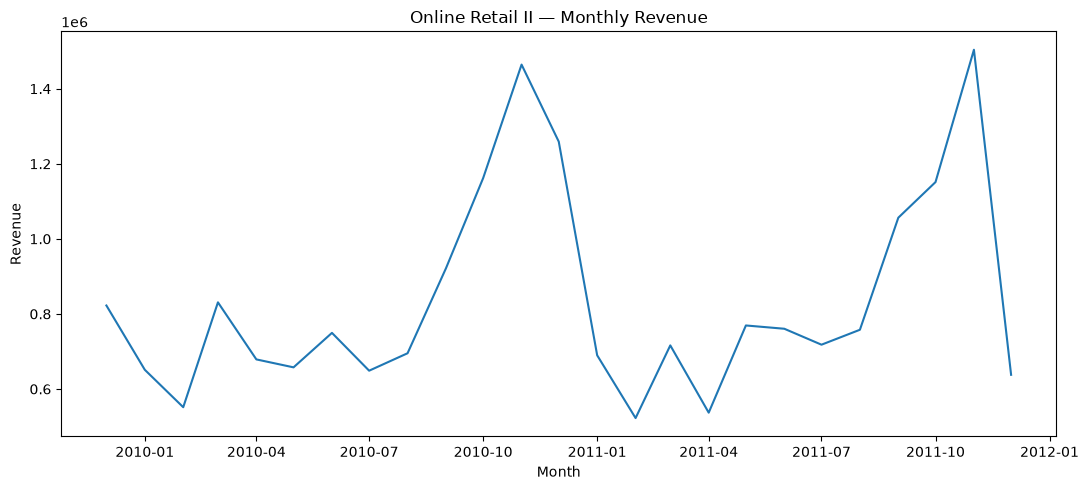

In [5]:

fig_monthly,ax=plt.subplots(figsize=(11,5)); ax.plot(monthly_metrics["month"],monthly_metrics["revenue"]); ax.set_title("Online Retail II — Monthly Revenue"); ax.set_xlabel("Month"); ax.set_ylabel("Revenue"); fig_monthly.tight_layout(); plt.show()


## 3. Product performance

In [6]:

product_metrics = retail.groupby(["StockCode","Description"],dropna=False).agg(revenue=("Revenue","sum"),units=("Quantity","sum"),orders=("Invoice","nunique"),customers=("CustomerID","nunique")).reset_index()
top_products_by_revenue = product_metrics.sort_values("revenue",ascending=False).head(20).copy()
top_products_by_units = product_metrics.sort_values("units",ascending=False).head(20).copy()
display(top_products_by_revenue)


,StockCode,Description,revenue,units,orders,customers
1875,22423,REGENCY CAKESTAND 3 TIER,344069.30,27536,3918,1314
5585,M,Manual,340327.63,9748,784,438
5584,DOT,DOTCOM POSTAGE,322657.48,1436,1415,1
4970,85123A,WHITE HANGING HEART T-LIGHT HOLDER,262589.96,95966,5356,1490
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1
3694,47566,PARTY BUNTING,149109.35,28362,2674,894
4939,85099B,JUMBO BAG RED RETROSPOT,148528.63,78698,3245,860
4612,84879,ASSORTED COLOUR BIRD ORNAMENT,131817.81,81590,2807,1010
5587,POST,POSTAGE,127597.42,5461,1851,405
1465,22086,PAPER CHAIN KIT 50'S CHRISTMAS,123002.89,36534,2018,896


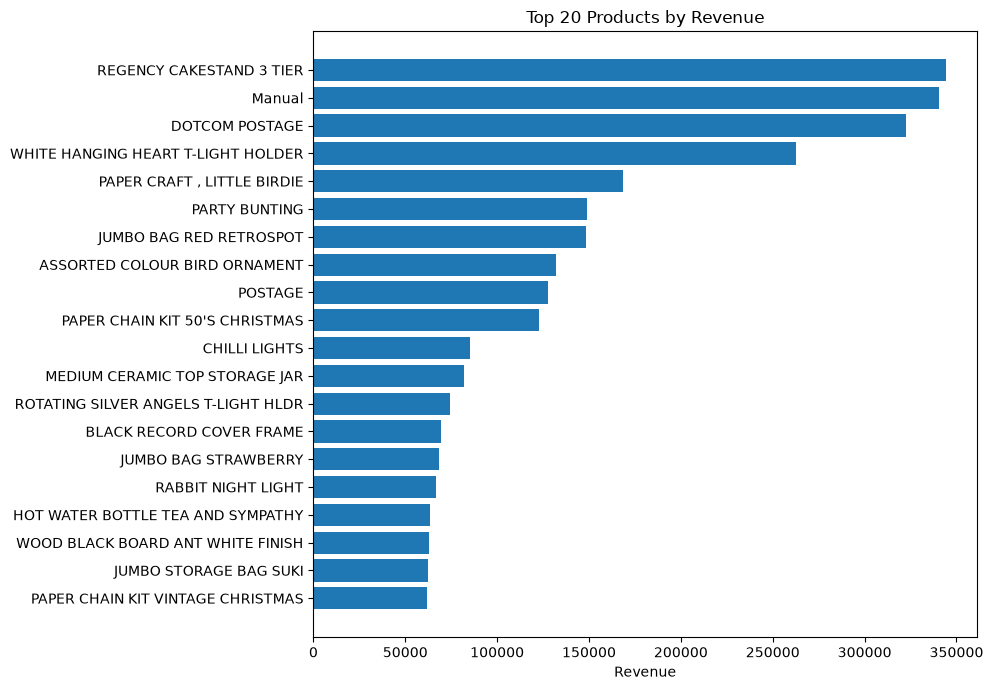

In [7]:

fig_products,ax=plt.subplots(figsize=(10,7)); plot_products=top_products_by_revenue.sort_values("revenue"); labels=plot_products["Description"].fillna(plot_products["StockCode"].astype(str)).astype(str).str.slice(0,45); ax.barh(labels,plot_products["revenue"]); ax.set_title("Top 20 Products by Revenue"); ax.set_xlabel("Revenue"); fig_products.tight_layout(); plt.show()


## 4. Country performance

In [8]:

country_metrics = retail.groupby("Country",dropna=False).agg(revenue=("Revenue","sum"),orders=("Invoice","nunique"),customers=("CustomerID","nunique"),units=("Quantity","sum")).reset_index().sort_values("revenue",ascending=False)
country_metrics["revenue_share_pct"]=(100*country_metrics["revenue"]/country_metrics["revenue"].sum()).round(3)
top_countries=country_metrics.head(20).copy(); display(top_countries)


,Country,revenue,orders,customers,units,revenue_share_pct
40,United Kingdom,1.781406e+07,36535,5350,9349186,85.178
11,EIRE,6.640501e+05,626,5,340054,3.175
26,Netherlands,5.542307e+05,228,22,383976,2.650
15,Germany,4.307038e+05,789,107,227769,2.059
14,France,3.567465e+05,622,95,275090,1.706
0,Australia,1.699006e+05,95,15,104080,0.812
34,Spain,1.091272e+05,154,41,50774,0.522
36,Switzerland,1.009890e+05,93,22,52872,0.483
35,Sweden,9.186982e+04,105,19,88633,0.439
10,Denmark,6.986219e+04,43,12,237925,0.334


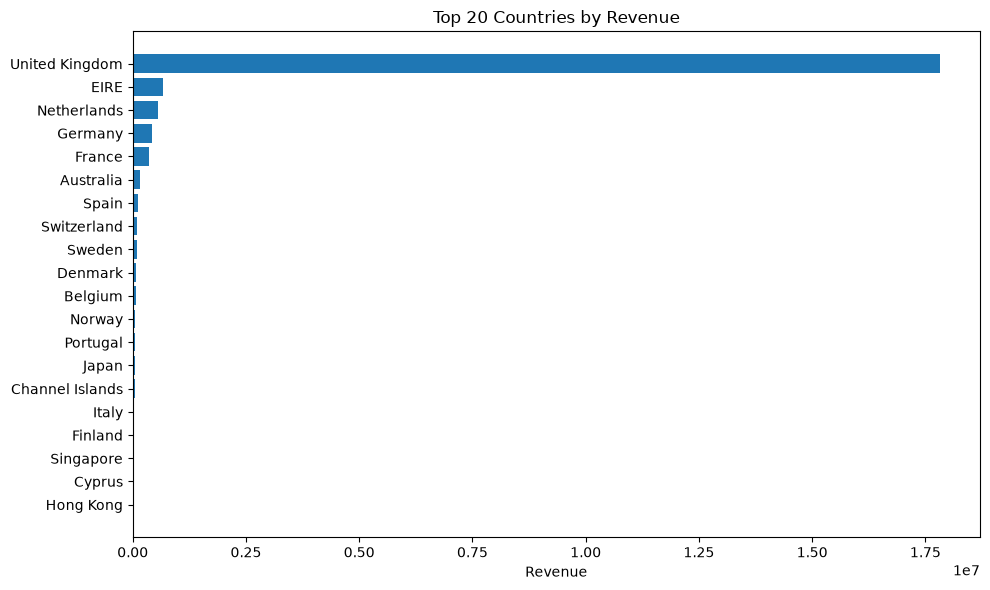

In [9]:

fig_countries,ax=plt.subplots(figsize=(10,6)); plot_countries=top_countries.sort_values("revenue"); ax.barh(plot_countries["Country"],plot_countries["revenue"]); ax.set_title("Top 20 Countries by Revenue"); ax.set_xlabel("Revenue"); fig_countries.tight_layout(); plt.show()


## 5. Customer value and repeat purchasing

In [10]:

customer_rows=retail.loc[retail["CustomerID"].notna()].copy()
customer_metrics=customer_rows.groupby("CustomerID").agg(orders=("Invoice","nunique"),revenue=("Revenue","sum"),units=("Quantity","sum"),unique_products=("StockCode","nunique"),first_purchase=("InvoiceDate","min"),last_purchase=("InvoiceDate","max")).reset_index()
customer_metrics["avg_order_value"]=customer_metrics["revenue"]/customer_metrics["orders"]
customer_metrics["repeat_buyer"]=customer_metrics["orders"]>=2
analysis_end=customer_rows["InvoiceDate"].max(); customer_metrics["recency_days"]=(analysis_end-customer_metrics["last_purchase"]).dt.days
customer_summary=pd.DataFrame({"metric":["identified_customers","repeat_buyers","repeat_buyer_pct","median_orders_per_customer","median_customer_revenue","mean_customer_revenue"],"value":[len(customer_metrics),int(customer_metrics["repeat_buyer"].sum()),round(100*customer_metrics["repeat_buyer"].mean(),3),round(customer_metrics["orders"].median(),3),round(customer_metrics["revenue"].median(),2),round(customer_metrics["revenue"].mean(),2)]})
top_customers=customer_metrics.sort_values("revenue",ascending=False).head(20).copy(); display(customer_summary); display(top_customers)


,metric,value
0,identified_customers,5878.000
1,repeat_buyers,4255.000
2,repeat_buyer_pct,72.389
3,median_orders_per_customer,3.000
4,median_customer_revenue,887.390
5,mean_customer_revenue,3008.750


,CustomerID,orders,revenue,units,unique_products,first_purchase,last_purchase,avg_order_value,repeat_buyer,recency_days
5692,18102,145,608821.65,188340,382,2009-12-01 09:24:00,2011-12-09 11:50:00,4198.770000,True,0
2277,14646,151,528602.52,367193,961,2009-12-02 16:52:00,2011-12-08 12:12:00,3500.678940,True,1
1789,14156,156,313759.82,165873,1446,2009-12-01 12:30:00,2011-11-30 10:54:00,2011.280897,True,9
2538,14911,398,295832.39,149949,2550,2009-12-01 11:41:00,2011-12-08 15:54:00,743.297462,True,0
5050,17450,51,246813.09,84700,144,2010-09-27 16:59:00,2011-12-01 13:29:00,4839.472353,True,7
1331,13694,143,196482.81,189205,896,2009-12-04 15:26:00,2011-12-06 09:32:00,1374.005664,True,3
5109,17511,60,175603.55,119656,657,2009-12-02 10:52:00,2011-12-07 10:12:00,2926.725833,True,2
4061,16446,2,168472.50,80997,3,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000,True,0
4295,16684,55,147142.77,104810,184,2009-12-07 12:56:00,2011-12-05 14:06:00,2675.323091,True,3
68,12415,28,144458.37,91447,498,2010-06-30 08:30:00,2011-11-15 14:22:00,5159.227500,True,23


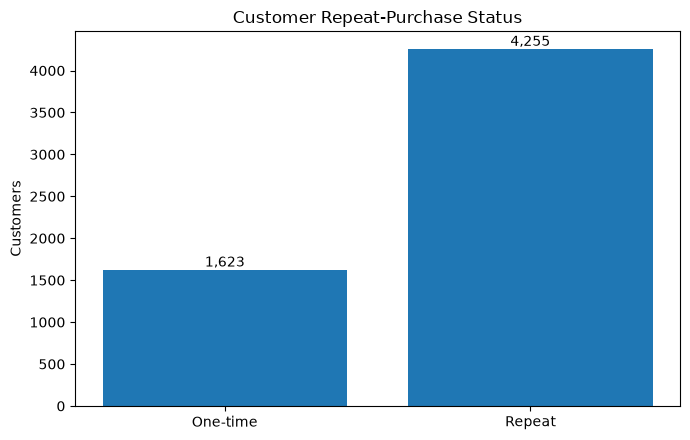

In [11]:

fig_repeat,ax=plt.subplots(figsize=(7,4.5)); repeat_counts=customer_metrics["repeat_buyer"].map({False:"One-time",True:"Repeat"}).value_counts().reindex(["One-time","Repeat"]); ax.bar(repeat_counts.index,repeat_counts.values); ax.set_title("Customer Repeat-Purchase Status"); ax.set_ylabel("Customers");
for i,v in enumerate(repeat_counts.values): ax.text(i,v,f"{v:,}",ha="center",va="bottom")
fig_repeat.tight_layout(); plt.show()


## 6. Save compact results

In [12]:

RESULTS_DIR=PROJECT_ROOT/"results"/"04_online_retail_customer_product_analytics"; TABLES_DIR=RESULTS_DIR/"tables"; FIGURES_DIR=RESULTS_DIR/"figures"; TABLES_DIR.mkdir(parents=True,exist_ok=True); FIGURES_DIR.mkdir(parents=True,exist_ok=True)
RESULT_TABLES={"business_overview":business_overview,"monthly_metrics":monthly_metrics,"top_products_by_revenue":top_products_by_revenue,"top_products_by_units":top_products_by_units,"top_countries":top_countries,"customer_summary":customer_summary,"top_customers":top_customers}
RESULT_FIGURES={"monthly_revenue":fig_monthly,"top_products_by_revenue":fig_products,"top_countries_by_revenue":fig_countries,"repeat_purchase_status":fig_repeat}
for name,table in RESULT_TABLES.items(): table.to_csv(TABLES_DIR/f"{name}.csv",index=False)
for name,fig in RESULT_FIGURES.items(): fig.savefig(FIGURES_DIR/f"{name}.png",dpi=200,bbox_inches="tight")
print(f"Tables saved : {len(RESULT_TABLES)}"); print(f"Figures saved: {len(RESULT_FIGURES)}"); print("Saved to:",RESULTS_DIR)


Tables saved : 7
Figures saved: 4
Saved to: /Users/noopur/Desktop/resume_projects/ProductPulse/results/04_online_retail_customer_product_analytics
